# 实验 3：Jupyter Notebook 基础实践

本实验用于熟悉 Jupyter Notebook 的基本使用流程，进一步练习 Python 基本语法，使用 Pandas 完成财富 500 强数据分析，并使用 Matplotlib 绘制利润和收入变化图。

Notebook 适合用于数据分析、模型实验和机器学习原型验证。本实验为后续 LiteRT 模型训练、数据预处理和移动端 AI 应用开发打基础。

## 1. Notebook 基本概念

Notebook 是一种交互式开发文档，可以把文字说明、Python 代码、运行输出、表格和图表放在同一个文件中。它非常适合课程实验，因为老师不仅能看到最终代码，也能看到每一步运行结果和分析过程。

Cell 是 Notebook 的基本组成单位。Markdown Cell 用于写标题、说明、表格和总结；Code Cell 用于写代码，运行后会在下方保留输出结果。

Notebook 常见两种模式：Edit 模式用于编辑 Cell 内容，Command 模式用于操作整个 Cell，例如新增、删除、移动或修改 Cell 类型。Kernel 是真正运行代码的 Python 进程，负责保存变量状态并返回输出。如果代码卡住，可以 Interrupt；如果想从零验证实验，可以 Restart Kernel 后 Run All。

| 快捷键 | 作用 |
|---|---|
| Enter | 进入 Edit 模式 |
| Esc | 进入 Command 模式 |
| Shift + Enter | 运行当前 Cell 并跳到下一个 |
| Ctrl + Enter | 运行当前 Cell |
| A | 在上方插入 Cell |
| B | 在下方插入 Cell |
| M | 转为 Markdown Cell |
| Y | 转为 Code Cell |
| DD | 删除 Cell |

## 2. 环境检查

先检查本 Notebook 实际使用的 Python、pandas、matplotlib 和 numpy 版本，方便老师复现实验。

In [1]:
import sys
import platform
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print("Python:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.19045-SP0
pandas: 2.3.3
matplotlib: 3.10.6
numpy: 2.3.5


## 3. Python 基本语法练习

本节用于复习 Python 中的变量、列表、循环、条件判断、函数和字符串格式化。后面的选择排序和数据分析都会用到这些基础语法。

In [2]:
student_name = "软件实践项目（三）学生"
experiment_no = 3
numbers = [64, 25, 12, 22, 11]

print(f"{student_name} 正在完成实验 {experiment_no}")
print("原始列表:", numbers)

for number in numbers:
    if number > 20:
        print(f"{number} 大于 20")
    else:
        print(f"{number} 小于或等于 20")


def describe_numbers(values):
    return f"列表长度为 {len(values)}，最大值为 {max(values)}，最小值为 {min(values)}"


print(describe_numbers(numbers))

软件实践项目（三）学生 正在完成实验 3
原始列表: [64, 25, 12, 22, 11]
64 大于 20
25 大于 20
12 小于或等于 20
22 大于 20
11 小于或等于 20
列表长度为 5，最大值为 64，最小值为 11


## 4. 选择排序 selection_sort

选择排序的思想是：每一轮从还没有排好序的数据里找出最小值，把它放到当前最前面的位置。就像排队时每次从剩下的小朋友里找个子最矮的，让他站到当前队伍最前面，重复几轮后，队伍就从矮到高排好了。

In [3]:
def selection_sort(data):
    """
    使用选择排序算法对数据进行升序排序。

    参数:
        data: 可迭代数字序列

    返回:
        排序后的新列表，不修改原始数据
    """
    arr = list(data)
    for i in range(len(arr)):
        min_index = i
        for j in range(i + 1, len(arr)):
            if arr[j] < arr[min_index]:
                min_index = j
        arr[i], arr[min_index] = arr[min_index], arr[i]
    return arr

## 5. test 函数测试 selection_sort

下面用多个测试用例验证 `selection_sort`。测试包含普通列表、逆序列表、已有序列表、重复元素、空列表、单元素列表和负数列表。

In [4]:
def test_selection_sort():
    test_cases = [
        [64, 25, 12, 22, 11],
        [5, 4, 3, 2, 1],
        [1, 2, 3, 4, 5],
        [3, 3, 2, 1, 2],
        [],
        [42],
        [-1, 5, 0, -3, 2]
    ]

    for case in test_cases:
        result = selection_sort(case)
        expected = sorted(case)
        print(f"输入: {case} -> 输出: {result}")
        assert result == expected, f"测试失败: {case}"

    print("所有 selection_sort 测试均通过！")


test_selection_sort()

输入: [64, 25, 12, 22, 11] -> 输出: [11, 12, 22, 25, 64]
输入: [5, 4, 3, 2, 1] -> 输出: [1, 2, 3, 4, 5]
输入: [1, 2, 3, 4, 5] -> 输出: [1, 2, 3, 4, 5]
输入: [3, 3, 2, 1, 2] -> 输出: [1, 2, 2, 3, 3]
输入: [] -> 输出: []
输入: [42] -> 输出: [42]
输入: [-1, 5, 0, -3, 2] -> 输出: [-3, -1, 0, 2, 5]
所有 selection_sort 测试均通过！


## 6. 模拟数据输入并排序

PPT 要求完成数据输入、排序和输出。为了保证 Notebook 可以从头到尾 Run All，这里不使用会阻塞执行的 `input()`，而是用字符串模拟用户输入。

In [5]:
def parse_numbers(text):
    return [int(item) for item in text.replace(",", " ").split()]


def test_user_input_sort():
    user_text = "64 25 12 22 11"
    numbers = parse_numbers(user_text)
    sorted_numbers = selection_sort(numbers)

    print("模拟输入:", user_text)
    print("解析结果:", numbers)
    print("排序结果:", sorted_numbers)


test_user_input_sort()

模拟输入: 64 25 12 22 11
解析结果: [64, 25, 12, 22, 11]
排序结果: [11, 12, 22, 25, 64]


> 可选交互说明：如果手动练习，可以额外写 `input()` 读取键盘输入；但它会阻塞 Run All，所以本实验主流程不使用交互式输入。

## 7. 使用 Pandas 读取 Fortune 500 数据

本节使用 Pandas 读取财富 500 强排名数据集，完成数据显示、列属性检查、异常值处理、数据过滤和属性查询。为了兼容从仓库根目录、实验目录或 notebooks 目录执行，下面使用多个候选路径查找 CSV。

In [6]:
possible_paths = [
    Path("../data/fortune500.csv"),
    Path("data/fortune500.csv"),
    Path("E3_Notebook_Basics/data/fortune500.csv"),
]

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError("未找到 fortune500.csv，请检查 data 目录。")

PROJECT_ROOT = DATA_PATH.parent.parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("数据文件:", DATA_PATH.resolve())
print("输出目录:", OUTPUT_DIR.resolve())

df = pd.read_csv(DATA_PATH)
df.head()

数据文件: H:\福建师范大学\大三下\软件实践研发（3）\E3_Notebook_Basics\data\fortune500.csv
输出目录: H:\福建师范大学\大三下\软件实践研发（3）\E3_Notebook_Basics\outputs


,Year,Rank,Company,Revenue (in millions),Profit (in millions)
0,1955,1,General Motors,9823.5,806
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1


## 8. 数据基本信息检查

通过 `shape`、列名、前几行、后几行、`info()` 和 `describe()` 观察数据结构。

In [7]:
print("数据规模:", df.shape)
print("列名:", list(df.columns))
display(df.head())
display(df.tail())

数据规模: (25500, 5)
列名: ['Year', 'Rank', 'Company', 'Revenue (in millions)', 'Profit (in millions)']


,Year,Rank,Company,Revenue (in millions),Profit (in millions)
0,1955,1,General Motors,9823.5,806
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1


,Year,Rank,Company,Revenue (in millions),Profit (in millions)
25495,2005,496,Wm. Wrigley Jr.,3648.6,493
25496,2005,497,Peabody Energy,3631.6,175.4
25497,2005,498,Wendy's International,3630.4,57.8
25498,2005,499,Kindred Healthcare,3616.6,70.6
25499,2005,500,Cincinnati Financial,3614.0,584


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   25500 non-null  int64  
 1   Rank                   25500 non-null  int64  
 2   Company                25500 non-null  object 
 3   Revenue (in millions)  25500 non-null  float64
 4   Profit (in millions)   25500 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 996.2+ KB


In [9]:
df.describe(include="all")

,Year,Rank,Company,Revenue (in millions),Profit (in millions)
count,25500.00000,25500.000000,25500,25500.000000,25500
unique,NaN,NaN,1887,NaN,6977
top,NaN,NaN,CBS,NaN,N.A.
freq,NaN,NaN,57,NaN,369
mean,1980.00000,250.499765,NaN,4273.329635,NaN
std,14.71989,144.339963,NaN,11351.884979,NaN
min,1955.00000,1.000000,NaN,49.700000,NaN
25%,1967.00000,125.750000,NaN,362.300000,NaN
50%,1980.00000,250.500000,NaN,1019.000000,NaN
75%,1993.00000,375.250000,NaN,3871.000000,NaN


## 9. 统一列名

原始数据列名为英文大写或带括号。为了后续分析方便，统一重命名为 `year`、`rank`、`company`、`revenue`、`profit`。

In [10]:
rename_map = {
    "Year": "year",
    "Rank": "rank",
    "Company": "company",
    "Revenue (in millions)": "revenue",
    "Profit (in millions)": "profit",
    "Revenue": "revenue",
    "Profit": "profit"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df.columns = [str(col).strip().lower() for col in df.columns]

required_columns = {"year", "rank", "company", "revenue", "profit"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"数据集缺少必要列: {missing_columns}")

df.head()

,year,rank,company,revenue,profit
0,1955,1,General Motors,9823.5,806
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1


## 10. 检查 profit 异常值

PPT 明确要求删除“利润 profit”列包含异常值的数据行。清洗前先展示这些异常值，确认它们确实存在。

In [11]:
print("profit 列的数据类型:", df["profit"].dtype)

abnormal_profit_rows = df[df["profit"].astype(str).str.contains("N.A.", na=False)]
print("profit 包含 N.A. 的行数:", len(abnormal_profit_rows))

display(abnormal_profit_rows.head())

profit 列的数据类型: object
profit 包含 N.A. 的行数: 369


,year,rank,company,revenue,profit
228,1955,229,Norton,135.0,N.A.
290,1955,291,Schlitz Brewing,100.0,N.A.
294,1955,295,Pacific Vegetable Oil,97.9,N.A.
296,1955,297,Liebmann Breweries,96.0,N.A.
352,1955,353,Minneapolis-Moline,77.4,N.A.


## 11. 删除 profit 异常值并转换数据类型

删除 `profit` 为 `N.A.` 的行后，再把年份、排名、收入和利润转换为数值类型。清洗后的预览会保存到 outputs 目录，方便老师直接检查。

In [12]:
df_clean = df[~df["profit"].astype(str).str.contains("N.A.", na=False)].copy()

df_clean["profit"] = pd.to_numeric(df_clean["profit"], errors="coerce")
df_clean["revenue"] = pd.to_numeric(df_clean["revenue"], errors="coerce")
df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce")
df_clean["rank"] = pd.to_numeric(df_clean["rank"], errors="coerce")

df_clean = df_clean.dropna(subset=["year", "rank", "revenue", "profit"])

print("清洗前数据规模:", df.shape)
print("清洗后数据规模:", df_clean.shape)
print("清洗后 profit 类型:", df_clean["profit"].dtype)

display(df_clean.head())

df_clean.head(20).to_csv(OUTPUT_DIR / "cleaned_fortune500_preview.csv", index=False)
print("清洗预览已保存:", (OUTPUT_DIR / "cleaned_fortune500_preview.csv").resolve())

清洗前数据规模: (25500, 5)
清洗后数据规模: (25131, 5)
清洗后 profit 类型: float64


,year,rank,company,revenue,profit
0,1955,1,General Motors,9823.5,806.0
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1


清洗预览已保存: H:\福建师范大学\大三下\软件实践研发（3）\E3_Notebook_Basics\outputs\cleaned_fortune500_preview.csv


## 12. 数据过滤与属性查询

下面完成几个常见查询：1955 年排名前 10 的公司、收入最高的 10 条记录、利润最高的 10 条记录，以及按年份统计平均收入和平均利润。

In [13]:
top_1955 = df_clean[df_clean["year"] == 1955].sort_values("rank").head(10)
display(top_1955)

,year,rank,company,revenue,profit
0,1955,1,General Motors,9823.5,806.0
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1
5,1955,6,Chrysler,2071.6,18.5
6,1955,7,Armour,2056.1,1.6
7,1955,8,Gulf Oil,1705.3,182.8
8,1955,9,Mobil,1703.6,183.8
9,1955,10,DuPont,1687.7,344.4


In [14]:
top_revenue = df_clean.sort_values("revenue", ascending=False).head(10)
display(top_revenue[["year", "rank", "company", "revenue", "profit"]])

,year,rank,company,revenue,profit
25000,2005,1,Wal-Mart Stores,288189.0,10267.0
25001,2005,2,Exxon Mobil,270772.0,25330.0
24500,2004,1,Wal-Mart Stores,258681.0,9054.0
24000,2003,1,Wal-Mart Stores,246525.0,8039.0
23500,2002,1,Wal-Mart Stores,219812.0,6671.0
24501,2004,2,Exxon Mobil,213199.0,21510.0
23000,2001,1,Exxon Mobil,210392.0,17720.0
24502,2004,3,General Motors,195645.2,3822.0
25002,2005,3,General Motors,193517.0,2805.0
23001,2001,2,Wal-Mart Stores,193295.0,6295.0


In [15]:
top_profit = df_clean.sort_values("profit", ascending=False).head(10)
display(top_profit[["year", "rank", "company", "revenue", "profit"]])

,year,rank,company,revenue,profit
25001,2005,2,Exxon Mobil,270772.0,25330.0
22001,1999,2,Ford Motor,144416.0,22071.0
24501,2004,2,Exxon Mobil,213199.0,21510.0
24507,2004,8,Citigroup,94713.0,17853.0
23000,2001,1,Exxon Mobil,210392.0,17720.0
25007,2005,8,Citigroup,108276.0,17046.0
25004,2005,5,General Electric,152363.0,16593.0
23501,2002,2,Exxon Mobil,191581.0,15320.0
24005,2003,6,Citigroup,100789.0,15276.0
24504,2004,5,General Electric,134187.0,15002.0


In [16]:
annual_summary = (
    df_clean
    .groupby("year", as_index=False)
    .agg(
        mean_revenue=("revenue", "mean"),
        mean_profit=("profit", "mean"),
        company_count=("company", "count")
    )
)

display(annual_summary.head())
display(annual_summary.tail())

,year,mean_revenue,mean_profit,company_count
0,1955,275.754453,16.732186,494
1,1956,323.604418,22.509237,498
2,1957,350.037626,23.181087,497
3,1958,377.977264,23.456740,497
4,1959,355.229376,19.279276,497


,year,mean_revenue,mean_profit,company_count
46,2001,14398.209859,893.058753,497
47,2002,14634.109073,415.736694,496
48,2003,13995.498990,140.546263,495
49,2004,14930.537000,891.185400,500
50,2005,16521.448096,1028.991182,499


## 13. Matplotlib 分别绘制利润和收入

基础实验要求分别绘制利润和收入。下面分别保存年度平均利润趋势图和年度平均收入趋势图。

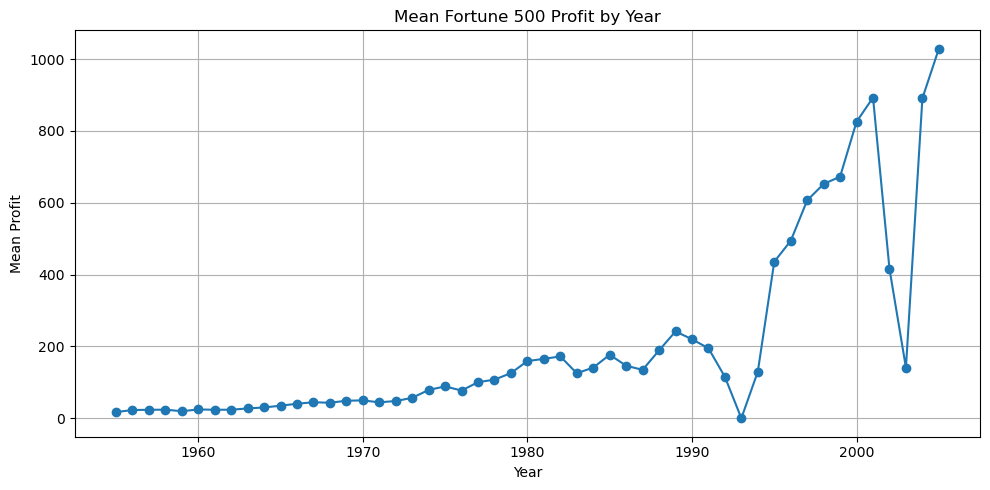

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(annual_summary["year"], annual_summary["mean_profit"], marker="o")
plt.title("Mean Fortune 500 Profit by Year")
plt.xlabel("Year")
plt.ylabel("Mean Profit")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "profit_trend.png", dpi=150)
plt.show()

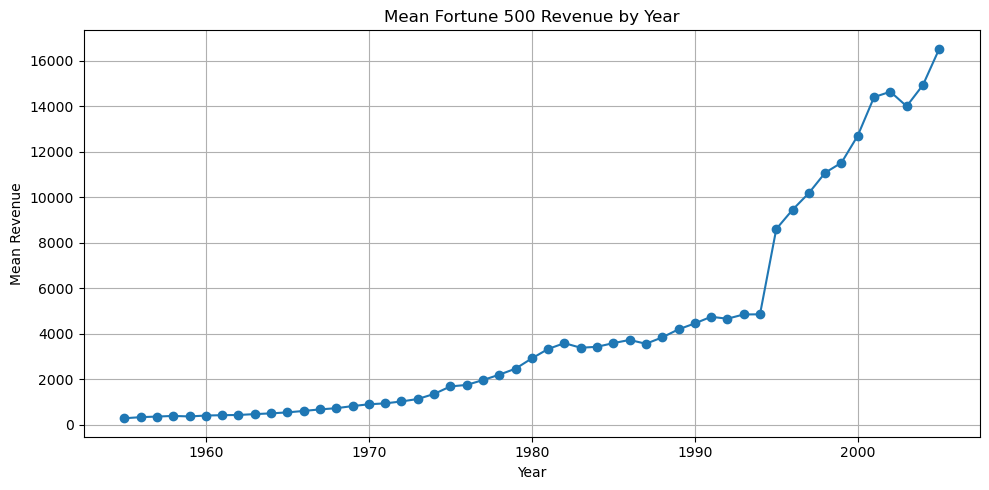

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(annual_summary["year"], annual_summary["mean_revenue"], marker="o")
plt.title("Mean Fortune 500 Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Mean Revenue")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "revenue_trend.png", dpi=150)
plt.show()

## 14. 一张图同时画利润和收入

收入和利润的数量级差距较大，直接放在同一个 y 轴上会让利润曲线不明显。因此这里完成两种清晰方案：双 y 轴图和归一化同轴图。

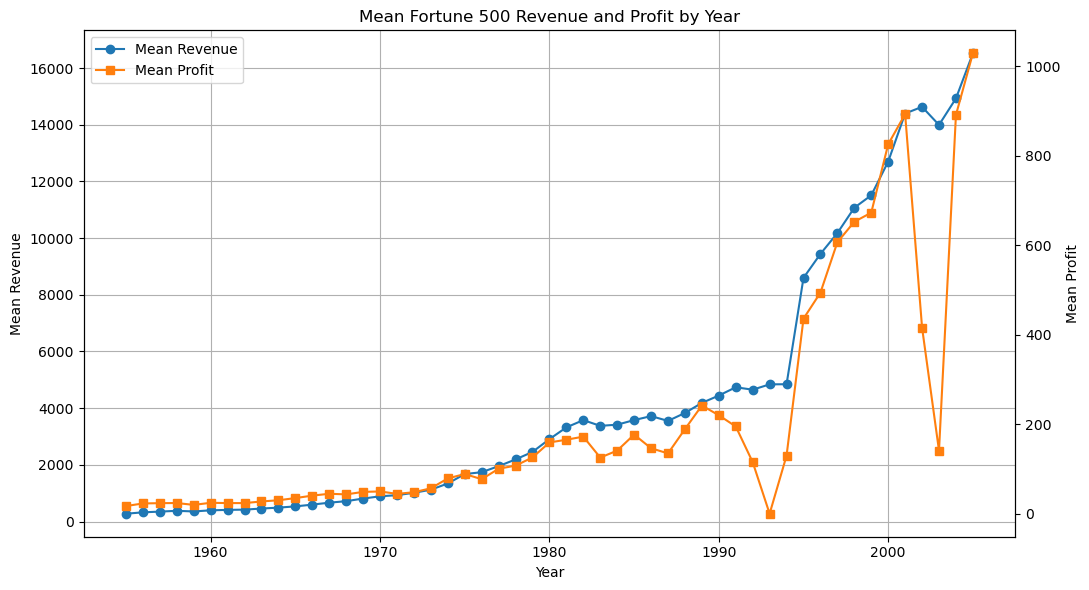

In [19]:
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(annual_summary["year"], annual_summary["mean_revenue"], marker="o", label="Mean Revenue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Mean Revenue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(annual_summary["year"], annual_summary["mean_profit"], marker="s", label="Mean Profit", color="tab:orange")
ax2.set_ylabel("Mean Profit")

plt.title("Mean Fortune 500 Revenue and Profit by Year")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "revenue_profit_combined.png", dpi=150)
plt.show()

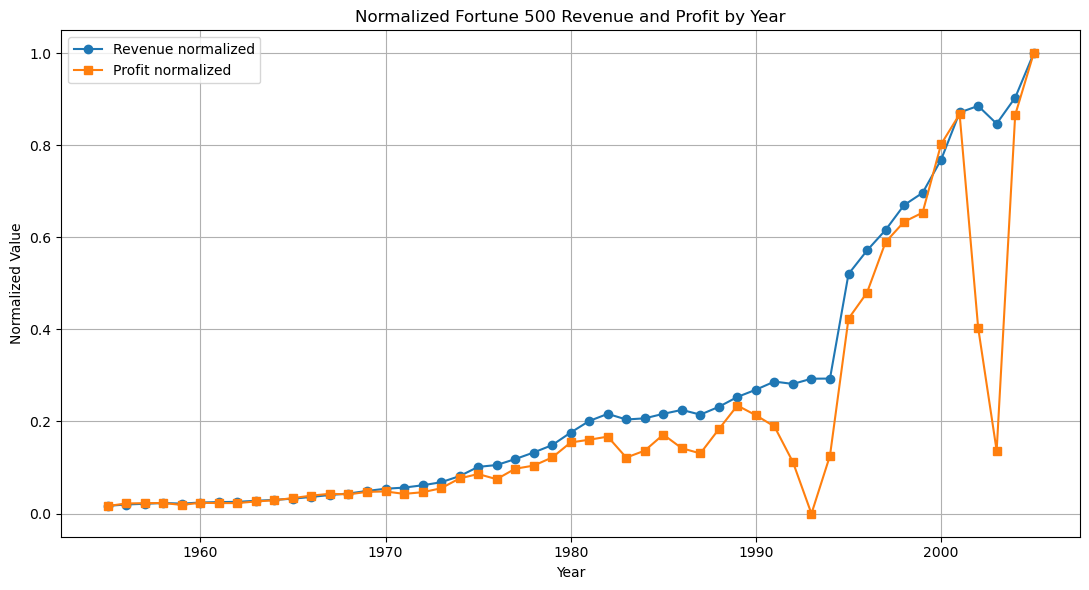

In [20]:
normalized = annual_summary.copy()
normalized["revenue_norm"] = normalized["mean_revenue"] / normalized["mean_revenue"].max()
normalized["profit_norm"] = normalized["mean_profit"] / normalized["mean_profit"].abs().max()

plt.figure(figsize=(11, 6))
plt.plot(normalized["year"], normalized["revenue_norm"], marker="o", label="Revenue normalized")
plt.plot(normalized["year"], normalized["profit_norm"], marker="s", label="Profit normalized")
plt.title("Normalized Fortune 500 Revenue and Profit by Year")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "revenue_profit_normalized.png", dpi=150)
plt.show()

## 实验总结

通过本实验，我掌握了 Jupyter Notebook 的基本使用方式，理解了 Cell、Edit 模式、Command 模式和 Kernel 的作用；通过 selection_sort 练习了 Python 函数、循环和测试；通过 Pandas 完成了 Fortune 500 数据读取、清洗、过滤和分组统计；通过 Matplotlib 绘制了收入和利润趋势图，并完成了一张图同时展示收入和利润的扩展任务。

本实验为后续 LiteRT 模型训练和移动 AI 应用开发打下基础，因为真实机器学习项目通常也需要先在 Notebook 中完成数据处理、实验验证和可视化分析，然后再将模型或结果迁移到 Android App 中。